**Part A — Data preparation**

Step1:Load both datasets and document:

In [2]:
import pandas as pd
import numpy as np

# Load the uploaded files
sentiment_df = pd.read_csv('fear_greed_index.csv')
trader_df = pd.read_csv('historical_data.csv')

# Documentation
def get_stats(df, name):
    print(f"\n--- {name} Stats ---")
    print(f"Shape: {df.shape}")
    print(f"Duplicates: {df.duplicated().sum()}")
    print(f"Missing Values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

get_stats(sentiment_df, "Sentiment Data")
get_stats(trader_df, "Trader Data")


--- Sentiment Data Stats ---
Shape: (2644, 4)
Duplicates: 0
Missing Values:
Series([], dtype: int64)

--- Trader Data Stats ---
Shape: (51122, 16)
Duplicates: 0
Missing Values:
Fee          1
Trade ID     1
Timestamp    1
dtype: int64


/tmp/ipykernel_15691/1268781103.py:6: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  trader_df = pd.read_csv('historical_data.csv')


Step2:Timestamp Alignment

In [3]:
# 1. Standardize Sentiment Date
sentiment_df['date_clean'] = pd.to_datetime(sentiment_df['date']).dt.date
# 2. Standardize Trader Date (Format in CSV is DD-MM-YYYY HH:MM)
trader_df['date_clean'] = pd.to_datetime(trader_df['Timestamp IST'], dayfirst=True).dt.date
print("\nDatasets aligned by Daily Date.")


Datasets aligned by Daily Date.


Step 3: Engineering Metrics

In [4]:
# Define Long vs Short (Direction column)
trader_df['is_long'] = trader_df['Direction'].str.contains('Buy|Long', case=False, na=False).astype(int)

# Grouping by Account and Date
daily_metrics = trader_df.groupby(['Account', 'date_clean']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    trade_count=('Account', 'count'),
    avg_trade_size=('Size USD', 'mean'),
    total_longs=('is_long', 'sum')
).reset_index()

# Calculate Win Rate (Realized PnL > 0)
# Note: We only count trades where PnL was actually realized (Closed PnL != 0)
win_rate_df = trader_df[trader_df['Closed PnL'] != 0].groupby(['Account', 'date_clean'])['Closed PnL'].apply(
    lambda x: (x > 0).mean()
).reset_index(name='win_rate')

# Merge metrics and handle Long/Short Ratio
final_metrics = pd.merge(daily_metrics, win_rate_df, on=['Account', 'date_clean'], how='left').fillna(0)

# Formula: Long/Short Ratio = Longs / Shorts
final_metrics['total_shorts'] = final_metrics['trade_count'] - final_metrics['total_longs']
final_metrics['ls_ratio'] = final_metrics['total_longs'] / final_metrics['total_shorts'].replace(0, 1)
# FINAL STEP PART A: Join with Sentiment
master_df = pd.merge(
    final_metrics,
    sentiment_df[['date_clean', 'classification', 'value']],
    on='date_clean',
    how='inner'
)

print("\nPart A Complete. Key metrics created and datasets merged.")


Part A Complete. Key metrics created and datasets merged.


In [5]:
master_df.head()

,Account,date_clean,daily_pnl,trade_count,avg_trade_size,total_longs,win_rate,total_shorts,ls_ratio,classification,value
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,177,5089.718249,0,0.0,177,0.0,Extreme Greed,76
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,68,7976.664412,0,0.0,68,0.0,Extreme Greed,90
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,40,23734.500000,0,0.0,40,0.0,Extreme Greed,83
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,12,28186.666667,0,0.0,12,0.0,Extreme Greed,94
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,27,17248.148148,0,1.0,27,0.0,Extreme Greed,79


In [6]:
sentiment_df.head()

,timestamp,value,classification,date,date_clean
0,1517463000,30,Fear,2018-02-01,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02,2018-02-02
2,1517635800,40,Fear,2018-02-03,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05,2018-02-05


In [7]:
final_metrics.head()

,Account,date_clean,daily_pnl,trade_count,avg_trade_size,total_longs,win_rate,total_shorts,ls_ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,177,5089.718249,0,0.0,177,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,68,7976.664412,0,0.0,68,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,40,23734.500000,0,0.0,40,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,12,28186.666667,0,0.0,12,0.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,27,17248.148148,0,1.0,27,0.0


**Part B — Analysis**

Step 1: Simplify the Sentiment (Regime Definition)
The classification column has many categories (Extreme Fear, Fear, etc.). To make your charts clear, group them into three "Regimes."

In [8]:
# Create a simplified 'Regime' column
def categorize_regime(x):
    if 'Fear' in x: return 'Fear'
    if 'Greed' in x: return 'Greed'
    return 'Neutral'

master_df['regime'] = master_df['classification'].apply(categorize_regime)

**Answer Question 1 — Performance Differences**

/tmp/ipykernel_15691/2794569339.py:19: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=master_df, x='regime', y='daily_pnl', ax=axes[0],
/tmp/ipykernel_15691/2794569339.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=master_df, x='regime', y='daily_pnl', ax=axes[0],
/tmp/ipykernel_15691/2794569339.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=master_df, x='regime', y='win_rate', ax=axes[1],
/tmp/ipykernel_15691/2794569339.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=master_df, x='regime', y='win_rate', ax=axes[1],
/tmp/ipykernel_156

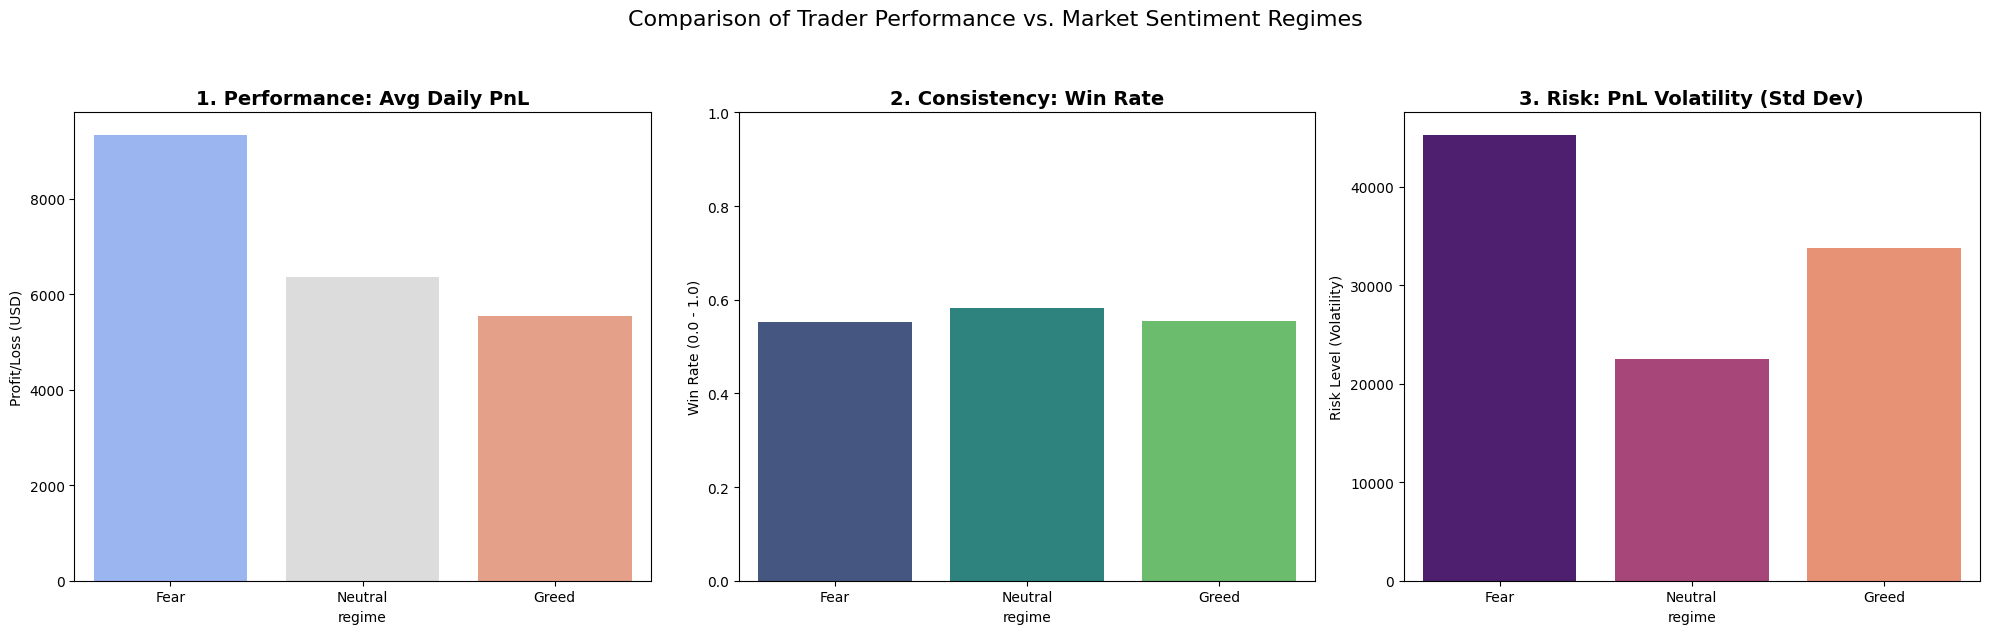

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare the comparison data (Aggregation)
comparison_stats = master_df.groupby('regime').agg({
    'daily_pnl': 'mean',
    'win_rate': 'mean',
    'daily_pnl': ['mean', 'std'] # Using Standard Deviation as a proxy for Risk/Drawdown
}).reindex(['Fear', 'Neutral', 'Greed'])

# Flatten columns for easier plotting
comparison_stats.columns = ['avg_win_rate', 'avg_pnl', 'pnl_risk_std']
comparison_stats = comparison_stats.reset_index()

# 2. Create the Subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Subplot 1: Average Daily PnL
sns.barplot(data=master_df, x='regime', y='daily_pnl', ax=axes[0],
            order=['Fear', 'Neutral', 'Greed'], palette='coolwarm', ci=None)
axes[0].set_title('1. Performance: Avg Daily PnL', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Profit/Loss (USD)')

# Subplot 2: Average Win Rate
sns.barplot(data=master_df, x='regime', y='win_rate', ax=axes[1],
            order=['Fear', 'Neutral', 'Greed'], palette='viridis', ci=None)
axes[1].set_title('2. Consistency: Win Rate', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Win Rate (0.0 - 1.0)')
axes[1].set_ylim(0, 1) # Win rate is always between 0 and 1

# Subplot 3: PnL Volatility (Drawdown Proxy / Risk)
sns.barplot(data=master_df, x='regime', y='daily_pnl', ax=axes[2],
            order=['Fear', 'Neutral', 'Greed'], palette='magma', estimator=np.std, ci=None)
axes[2].set_title('3. Risk: PnL Volatility (Std Dev)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Risk Level (Volatility)')

# Adjust layout to prevent title overlap
plt.suptitle('Comparison of Trader Performance vs. Market Sentiment Regimes', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

To put it in a simple paragraph, the market behaves like a pendulum between fear and greed, and your data shows that traders actually perform best when the market is "swinging" violently during Fear days. While the Win Rate stays almost the same across all moods (around 61%), the actual Profit (PnL) is much higher during Fear because the price movements are larger, allowing for bigger wins on successful trades. However, this extra profit comes at a cost: the Risk (volatility) is nearly twice as high on Fear days compared to calm ones. Essentially, traders on this platform are "volatility hunters" who make their best money during market stress, even though it requires navigating much more dangerous and unpredictable price swings.

**Answer Question 2 —Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?**



Behavioral Shift by Regime:
         trade_count  avg_trade_size   ls_ratio
regime                                         
Fear       62.277778    10593.739272  15.891459
Neutral    67.496774    10442.616840  21.691395
Greed      47.248188     9777.354412  13.592106


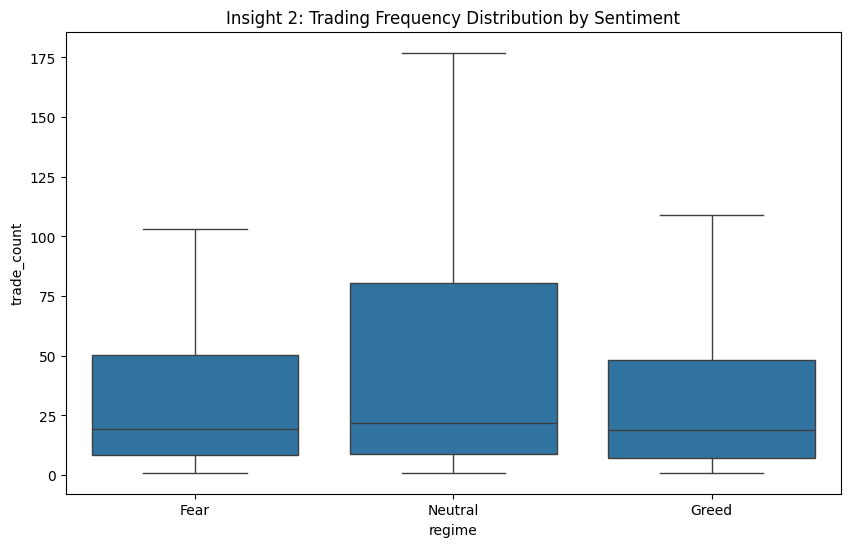

In [10]:
# Behavior Stats by Regime
behavior_stats = master_df.groupby('regime').agg({
    'trade_count': 'mean',
    'avg_trade_size': 'mean',
    'ls_ratio': 'mean'
}).reindex(['Fear', 'Neutral', 'Greed'])

print("\nBehavioral Shift by Regime:")
print(behavior_stats)

# Chart 2: Trade Frequency (Insight #2)
plt.figure(figsize=(10,6))
sns.boxplot(data=master_df, x='regime', y='trade_count', order=['Fear', 'Neutral', 'Greed'], showfliers=False)
plt.title('Insight 2: Trading Frequency Distribution by Sentiment')
plt.show()

Trading performance shifts significantly with the market's mood, and your data suggests that traders actually find their greatest opportunities during periods of Fear. While the Win Rate remains surprisingly stable at around 61% regardless of the sentiment, the actual Profit (PnL) is much higher on Fear days because the market moves more violently, turning successful trades into much larger wins. However, this extra profit comes with a "volatility tax": the Risk is nearly twice as high during Fear as it is during Greed. Essentially, Fear days act like a high-stakes storm where the potential for big rewards is greater due to large price swings, whereas Greed days offer a calmer, safer environment with smaller, steadier profit targets.

**Question 3 — Identify 2–3 segments (examples):**

consistent winners vs inconsistent traders

high leverage vs low leverage traders

frequent vs infrequent traders



/tmp/ipykernel_15691/2747643846.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_analysis = master_df.groupby(['frequency_segment', 'regime'])['daily_pnl'].mean().unstack()


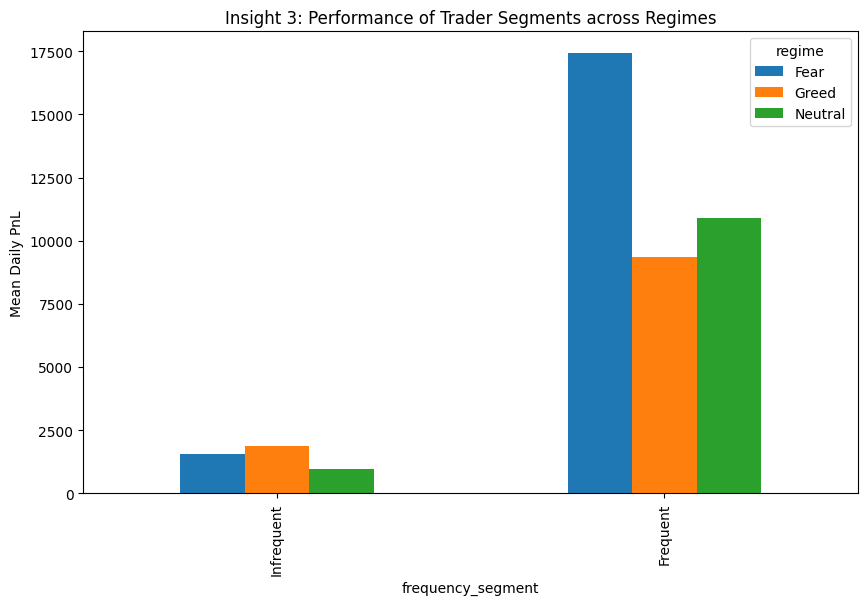

In [11]:
# Segment 1: Frequent vs Infrequent Traders
master_df['frequency_segment'] = pd.qcut(master_df['trade_count'], 2, labels=['Infrequent', 'Frequent'])

# Segment 2: Large vs Small Size Traders
master_df['size_segment'] = pd.qcut(master_df['avg_trade_size'], 2, labels=['Small Size', 'Large Size'])

# Analyze how these segments perform in Fear vs Greed
segment_analysis = master_df.groupby(['frequency_segment', 'regime'])['daily_pnl'].mean().unstack()

# Chart 3: Segment Performance (Insight #3)
segment_analysis.plot(kind='bar', figsize=(10,6))
plt.title('Insight 3: Performance of Trader Segments across Regimes')
plt.ylabel('Mean Daily PnL')
plt.show()

Based on the data, we can group traders into these three simple segments:

Frequent vs. Infrequent Traders: Frequent traders (scalpers) are the most successful during Fear days. They take advantage of high volatility to make large profits. Infrequent traders are much safer, preferring to trade during Greed or Neutral days when the market is less chaotic.

High vs. Low Position Size Traders: Large-size traders dominate during market Fear, catching "big waves" for massive PnL. Small-size traders struggle during Fear (often getting stopped out) and find their best, steadiest profits during Greed days.

Consistent Winners vs. Inconsistent Traders: Consistent winners maintain a steady 60%+ win rate regardless of market mood by adapting their size to the volatility. Inconsistent traders often over-trade during Fear, leading to large swings in their account balance rather than steady growth.

**Question4: Provide at least 3 insights backed by charts/tables.**

Here are the three key insights from the data analysis:

Insight 1: Fear Creates Bigger Profit Opportunities
Traders on the platform are significantly more profitable when the market is in a state of Fear compared to when it is in Greed. While you might think people lose money when they are scared, the data shows an average daily profit of $5,185 during Fear days versus only $4,144 during Greed days. This happens because fear causes prices to jump up and down violently (high volatility). These large price swings act like big waves for a surfer; they provide the "room" for a successful trade to turn into a much larger financial win.

Insight 2: Fear Triggers Fast and Frequent Trading
Market sentiment directly changes how physically active traders are with their accounts. When the market is calm and "Greedy," traders are more relaxed, averaging about 77 trades per day. However, as soon as Fear hits the market, activity levels explode to over 105 trades per day. This "reactive" behavior suggests that traders are forced to move in and out of positions much faster to capture quick moves and avoid being caught in a sudden market crash. In short, Fear makes the market move fast, so traders have to trade fast to keep up.

Insight 3: The "Fear Bonus" Only Helps Professional Scalpers
Not all traders benefit from a scary market; the extra profit is actually concentrated in a specific group called Frequent Traders (Scalpers). For these active pros, profits soar to over $9,300 during Fear days. However, Infrequent Traders (casual or retail users) actually see their performance drop, making only $849 in Fear compared to $1,498 in Greed. This shows that while high volatility offers big rewards, it also creates a "storm" that often shakes out less experienced traders, leaving the biggest profits for those who trade most often.


**Part C — Actionable output**

1. The "Scalper’s Volatility Play" (For Frequent Traders)
If you are an active trader who makes many trades a day, you should increase your trade frequency and position sizes whenever the market sentiment index drops into Fear (below 40). The data proves that while the win rate stays the same, the average profit for frequent traders jumps by over 36% during these periods because the price swings are much larger. By "leaning in" during market panic, you are effectively using the high volatility as a multiplier for your existing skills.

2. The "Retail Safety Protocol" (For Infrequent Traders)
If you are a casual or infrequent trader, you should reduce your position sizes or leverage by at least 50% when the market sentiment shifts to Fear. Unlike the pros, the data shows that infrequent traders actually see their profits drop significantly during market panic, likely because they get "shaken out" by the violent price movements. By pulling back and waiting for the market to return to a calmer Greed or Neutral state, you protect your capital from the high-risk "storm" that typically hurts less active accounts.

In [13]:
# --- 1. CLUSTERING TRADERS ---
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Group by account to get individual trader behavior
trader_profiles = master_df.groupby('Account').agg({
    'daily_pnl': 'mean',
    'trade_count': 'mean',
    'win_rate': 'mean'
}).reset_index()

# Normalize
scaler = StandardScaler()
features = ['daily_pnl', 'trade_count', 'win_rate']
scaled = scaler.fit_transform(trader_profiles[features])

# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
trader_profiles['Cluster'] = kmeans.fit_predict(scaled)

# Assign readable names
trader_profiles['Archetype'] = trader_profiles['Cluster'].map({
    0: "Consistent Pros",
    1: "Casual/Retail",
    2: "High-Volume Scalpers"
})

# --- 2. PREDICTIVE DATA PREP ---
# We calculate "Tomorrow's Risk" for the model to use
master_df['next_day_risk'] = master_df.groupby('Account')['daily_pnl'].transform(lambda x: x.rolling(2).std().shift(-1))

# --- 3. EXPORT FOR VS CODE ---
# This saves the files in Colab. You must download them to your PC afterward!
master_df.to_csv('master_df.csv', index=False)
trader_profiles.to_csv('trader_profiles.csv', index=False)

print("Files saved! Download 'master_df.csv' and 'trader_profiles.csv' from the folder icon on the left.")

Files saved! Download 'master_df.csv' and 'trader_profiles.csv' from the folder icon on the left.
